<a href="https://colab.research.google.com/github/ary3120-droid/myproject/blob/main/sp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

매출이 Buyer 때문인지 AOV 때문인지

매출 높은 날 vs 일반 날 비교

각 지표와 매출 관계 확인


In [35]:
!apt-get install -y fonts-nanum -qq

In [52]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 폰트 확인
for font in fm.findSystemFonts():
    if 'Nanum' in font:
        print(font)

# 실제 폰트 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())
plt.rcParams['axes.unicode_minus'] = False

/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf


In [54]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False

print(font_prop.get_name())

NanumGothic


In [56]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

print(font_name)

NanumGothic


In [37]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd

SP_PATH = '/content/drive/MyDrive/project_data/sales_performance_2025_01_01_2025_06_30.csv'

raw = pd.read_csv(SP_PATH)
print(raw.head())

   index          날짜 요일  시간대  결제자수  결제수  모바일비율(결제건수)     결제금액  모바일비율(결제금액)  \
0      0  2025-06-30  월  19시     1    1          1.0   894000          1.0   
1      1  2025-06-30  월  20시     0    0          NaN        0          NaN   
2      2  2025-06-29  일  22시     1    1          1.0  1327000          1.0   
3      3  2025-06-29  일  20시     1    1          1.0  1107000          1.0   
4      4  2025-06-27  금  22시     1    2          1.0  2456000          1.0   

    결제당 결제금액  ...  결제당 상품수량  배송비   쿠폰합계   상품쿠폰  주문쿠폰  환불건수     환불금액  \
0   894000.0  ...       2.0    0  10000  10000     0     0        0   
1        NaN  ...       NaN    0      0      0     0     1  1228000   
2  1327000.0  ...       4.0    0      0      0     0     0        0   
3  1107000.0  ...       5.0    0  10000  10000     0     0        0   
4  1228000.0  ...       4.0    0  20000  20000     0     1  1228000   

   환불비율(결제금액)  환불수량  환불비율(결제상품수량)  
0         0.0     0           0.0  
1         NaN     4           Na

In [39]:
if 'index' in raw.columns:
    raw = raw.drop(columns=['index'])

raw['날짜'] = pd.to_datetime(raw['날짜'])

num_cols = [
    '결제자수', '결제수', '결제금액', '결제상품수량',
    '배송비', '쿠폰합계', '상품쿠폰', '주문쿠폰',
    '환불건수', '환불금액', '환불수량'
]

for c in num_cols:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

In [40]:
agg_dict = {}

sum_cols = [
    '결제자수', '결제수', '결제금액', '결제상품수량',
    '배송비', '쿠폰합계', '상품쿠폰', '주문쿠폰',
    '환불건수', '환불금액', '환불수량'
]

for c in sum_cols:
    if c in raw.columns:
        agg_dict[c] = 'sum'

daily = (
    raw.groupby('날짜', as_index=False)
       .agg(agg_dict)
       .sort_values('날짜')
       .copy()
)

print(daily.shape)
print(daily.head())

(128, 12)
          날짜  결제자수  결제수     결제금액  결제상품수량  배송비  쿠폰합계  상품쿠폰  주문쿠폰  환불건수  환불금액  \
0 2025-01-03     2    2  1857000       4    0     0     0     0     0     0   
1 2025-01-04     2    2  2047000       4    0     0     0     0     0     0   
2 2025-01-05     2    2  1398000       3    0     0     0     0     0     0   
3 2025-01-06     1    1   824000       3    0     0     0     0     0     0   
4 2025-01-09     1    1   950000       1    0     0     0     0     0     0   

   환불수량  
0     0  
1     0  
2     0  
3     0  
4     0  


##피처 생성

In [41]:
def safe_div(a, b):
    return np.where((b == 0) | (pd.isna(b)), np.nan, a / b)

daily['buyer_count'] = daily['결제자수']
daily['order_count'] = daily['결제수']
daily['sales_amount'] = daily['결제금액']

daily['AOV'] = safe_div(daily['sales_amount'], daily['order_count'])
daily['orders_per_buyer'] = safe_div(daily['order_count'], daily['buyer_count'])
daily['revenue_per_buyer'] = safe_div(daily['sales_amount'], daily['buyer_count'])

daily = daily.replace([np.inf, -np.inf], np.nan)

cols = [
    '날짜', 'sales_amount', 'buyer_count', 'order_count',
    'AOV', 'orders_per_buyer', 'revenue_per_buyer'
]

print(daily[cols].head())
print(daily[cols[1:]].describe().T)

          날짜  sales_amount  buyer_count  order_count        AOV  \
0 2025-01-03       1857000            2            2   928500.0   
1 2025-01-04       2047000            2            2  1023500.0   
2 2025-01-05       1398000            2            2   699000.0   
3 2025-01-06        824000            1            1   824000.0   
4 2025-01-09        950000            1            1   950000.0   

   orders_per_buyer  revenue_per_buyer  
0               1.0           928500.0  
1               1.0          1023500.0  
2               1.0           699000.0  
3               1.0           824000.0  
4               1.0           950000.0  
                   count          mean           std      min       25%  \
sales_amount       128.0  1.730192e+06  1.218217e+06  30000.0  889250.0   
buyer_count        128.0  1.882812e+00  1.062022e+00      1.0       1.0   
order_count        128.0  2.000000e+00  1.229557e+00      1.0       1.0   
AOV                128.0  8.639508e+05  2.847101e+0

sales_amount         1.000000
order_count          0.884611
buyer_count          0.857912
revenue_per_buyer    0.478314
AOV                  0.403896
orders_per_buyer     0.183379
Name: sales_amount, dtype: float64


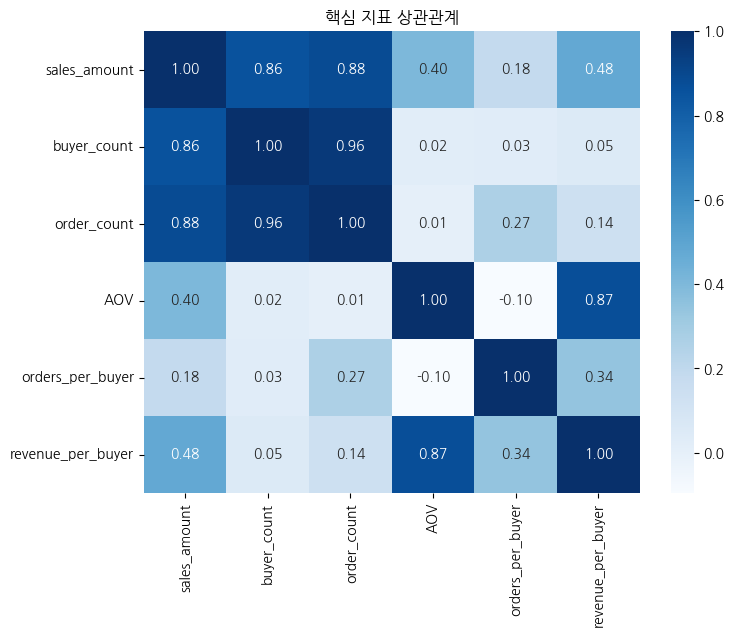

In [57]:
corr_df = daily[
    ['sales_amount', 'buyer_count', 'order_count', 'AOV', 'orders_per_buyer', 'revenue_per_buyer']
].corr()

print(corr_df['sales_amount'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('핵심 지표 상관관계')
plt.show()

##매출 vs Buyer / AOV 산점도

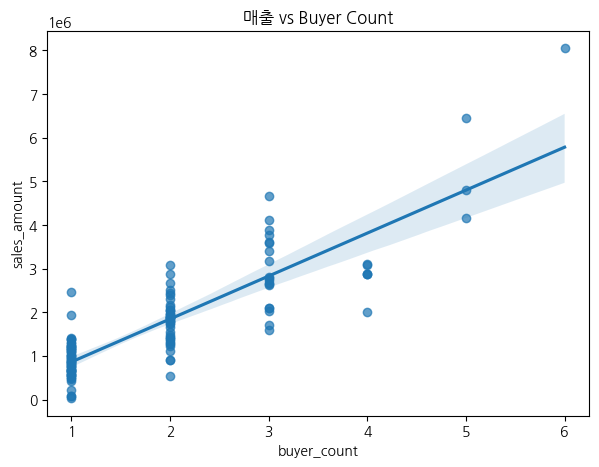

In [58]:
plt.figure(figsize=(7, 5))
sns.regplot(data=daily, x='buyer_count', y='sales_amount', scatter_kws={'alpha':0.7})
plt.title('매출 vs Buyer Count')
plt.show()

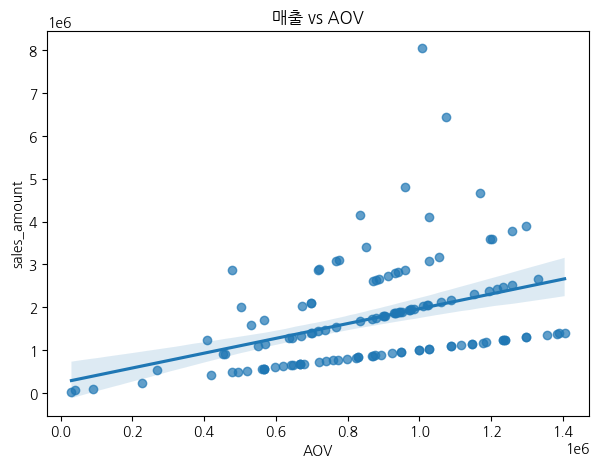

In [59]:
plt.figure(figsize=(7, 5))
sns.regplot(data=daily, x='AOV', y='sales_amount', scatter_kws={'alpha':0.7})
plt.title('매출 vs AOV')
plt.show()

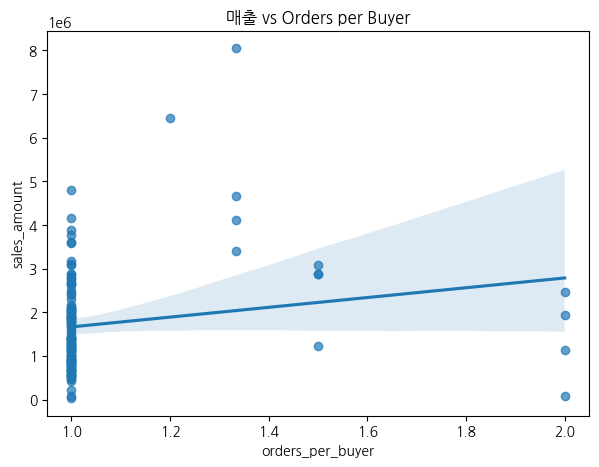

In [60]:
plt.figure(figsize=(7, 5))
sns.regplot(data=daily, x='orders_per_buyer', y='sales_amount', scatter_kws={'alpha':0.7})
plt.title('매출 vs Orders per Buyer')
plt.show()

##매출 높은 날 정의

In [46]:
threshold = daily['sales_amount'].quantile(0.75)
daily['high_sales_day'] = np.where(daily['sales_amount'] >= threshold, 1, 0)

print('매출 높은 날 기준:', threshold)
print(daily['high_sales_day'].value_counts())

매출 높은 날 기준: 2134500.0
high_sales_day
0    96
1    32
Name: count, dtype: int64


##높은 날 vs 일반 날 평균 비교

In [47]:
compare_cols = ['sales_amount', 'buyer_count', 'AOV', 'orders_per_buyer', 'revenue_per_buyer']

summary = daily.groupby('high_sales_day')[compare_cols].mean().T
summary.columns = ['일반 날 평균', '매출 높은 날 평균']
summary['증가배수'] = summary['매출 높은 날 평균'] / summary['일반 날 평균']

print(summary.round(2))

                      일반 날 평균  매출 높은 날 평균  증가배수
sales_amount       1185693.75  3363687.50  2.84
buyer_count              1.47        3.12  2.13
AOV                 815801.39  1008399.09  1.24
orders_per_buyer         1.04        1.13  1.09
revenue_per_buyer   834419.44  1134298.96  1.36


##높은 날 vs 일반 날 boxplot

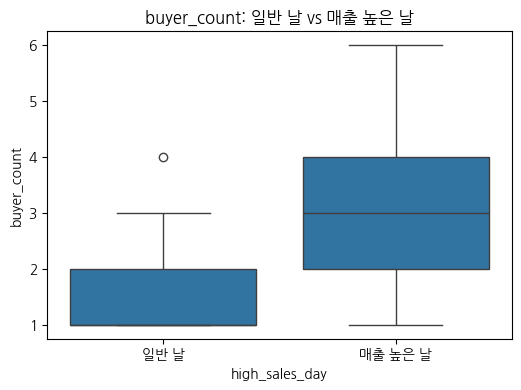

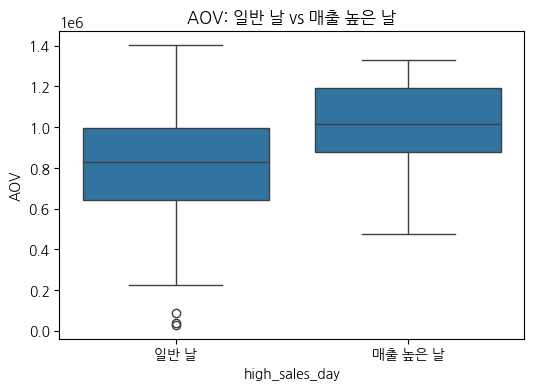

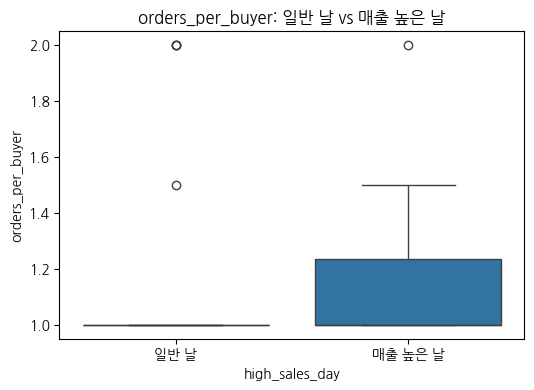

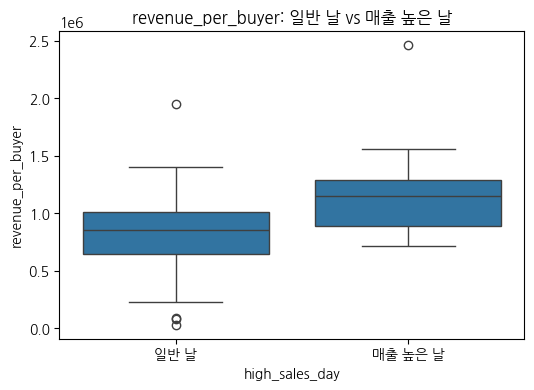

In [61]:
for col in ['buyer_count', 'AOV', 'orders_per_buyer', 'revenue_per_buyer']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=daily, x='high_sales_day', y=col)
    plt.xticks([0, 1], ['일반 날', '매출 높은 날'])
    plt.title(f'{col}: 일반 날 vs 매출 높은 날')
    plt.show()

##일별 매출 추이

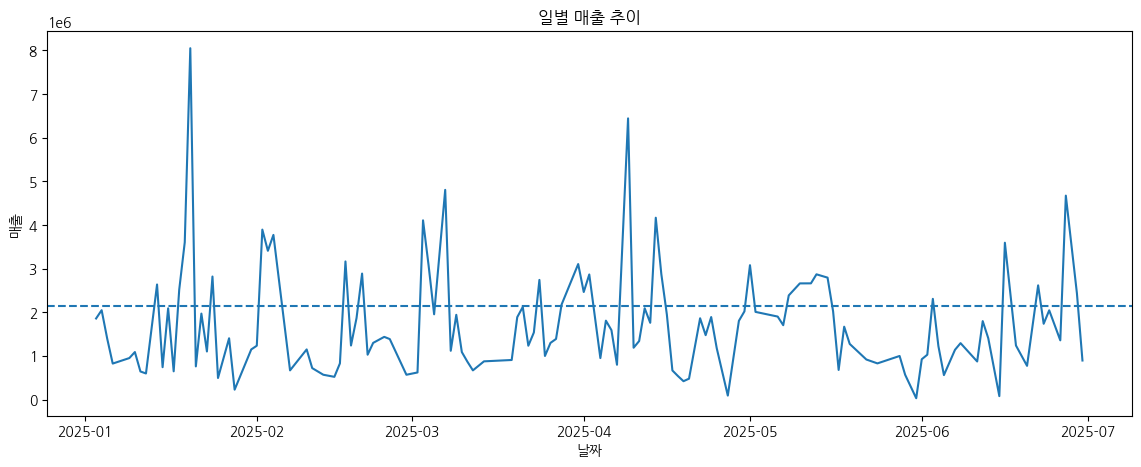

In [62]:
plt.figure(figsize=(14, 5))
plt.plot(daily['날짜'], daily['sales_amount'])
plt.axhline(threshold, linestyle='--')
plt.title('일별 매출 추이')
plt.xlabel('날짜')
plt.ylabel('매출')
plt.show()

##Buyer / AOV 추이 같이 보기

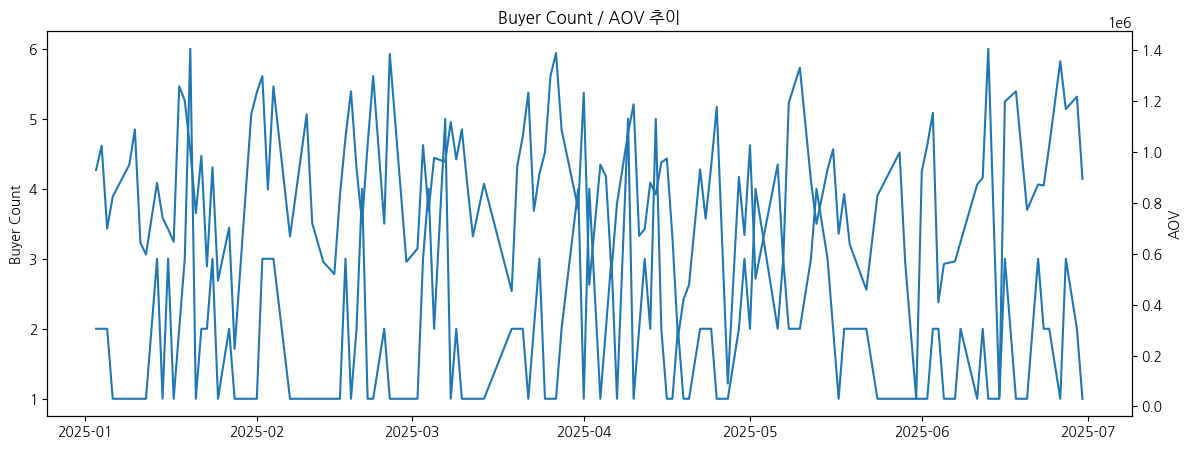

In [63]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(daily['날짜'], daily['buyer_count'], label='Buyer Count')
ax1.set_ylabel('Buyer Count')

ax2 = ax1.twinx()
ax2.plot(daily['날짜'], daily['AOV'], label='AOV')
ax2.set_ylabel('AOV')

plt.title('Buyer Count / AOV 추이')
plt.show()

##한 줄 해석용 출력

In [64]:
buyer_ratio = summary.loc['buyer_count', '증가배수']
aov_ratio = summary.loc['AOV', '증가배수']
opb_ratio = summary.loc['orders_per_buyer', '증가배수']

print(f'Buyer Count 증가배수: {buyer_ratio:.2f}배')
print(f'AOV 증가배수: {aov_ratio:.2f}배')
print(f'Orders per Buyer 증가배수: {opb_ratio:.2f}배')

if buyer_ratio > aov_ratio:
    print('=> 매출 높은 날은 AOV보다 Buyer 증가 영향이 더 큼')
elif aov_ratio > buyer_ratio:
    print('=> 매출 높은 날은 Buyer보다 AOV 증가 영향이 더 큼')
else:
    print('=> Buyer와 AOV 영향이 비슷함')

Buyer Count 증가배수: 2.13배
AOV 증가배수: 1.24배
Orders per Buyer 증가배수: 1.09배
=> 매출 높은 날은 AOV보다 Buyer 증가 영향이 더 큼


In [65]:
OUT_PATH = '/content/drive/MyDrive/project_data/sp_daily_featured.csv'
daily.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')
print('저장 완료:', OUT_PATH)

저장 완료: /content/drive/MyDrive/project_data/sp_daily_featured.csv
